# **Bivariate Analysis — Relationships Between Variables**

## INFO 442  Group 5  Shuyang Zhang 320230942711

### **1. Means hide overlap. Compute the mean and the std of body_mass_g for each species (or box-plot it: sns.boxplot(data=df, x="species", y="body_mass_g")). Gentoo are the heaviest — but do the species overlap? If someone told you a penguin weighs 4500 g, could you confidently name its species? Explain why "compare the means" alone doesn't answer that.**

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv("penguins.csv")

print("Setup complete. Shape:", df.shape)
df.head()

Setup complete. Shape: (344, 7)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


             mean    std
species                 
Adelie     3700.7  458.6
Chinstrap  3733.1  384.3
Gentoo     5076.0  504.1


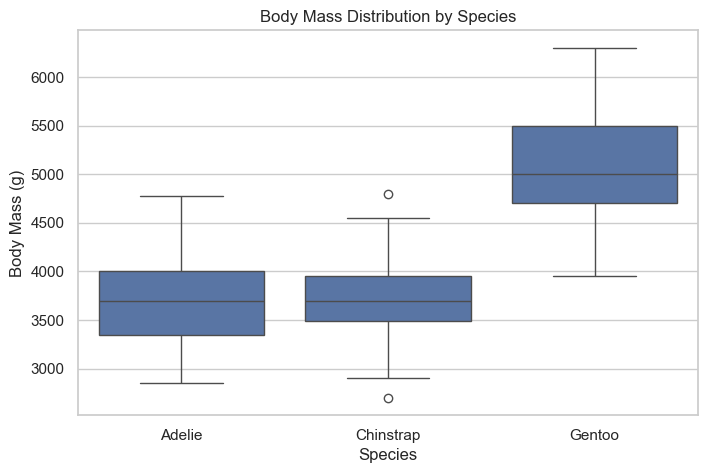

In [6]:
group_stats = df.groupby("species")["body_mass_g"].agg(["mean", "std"])
print(group_stats.round(1))

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="species", y="body_mass_g")
plt.title("Body Mass Distribution by Species")
plt.xlabel("Species")
plt.ylabel("Body Mass (g)")
plt.show()

**Answer:**

The species overlap substantially. Gentoo has the highest mean, but its standard deviation is 504g, meaning many Gentoos fall below 4500g. Meanwhile, Chinstrap has individuals above 4500g. A penguin weighing 4500g could be a large Chinstrap or a small Gentoo, so we could not confidently name its species based solely on weight. "Compare the means" alone doesn't answer this because means hide the overlap in distributions，we need to examine the full range and spread to understand whether groups are truly separable.

### **2. Make a scatter plot of bill_length_mm (x) vs. bill_depth_mm (y), coloured by species. Describe what the colours reveal that a plain scatter hides.**

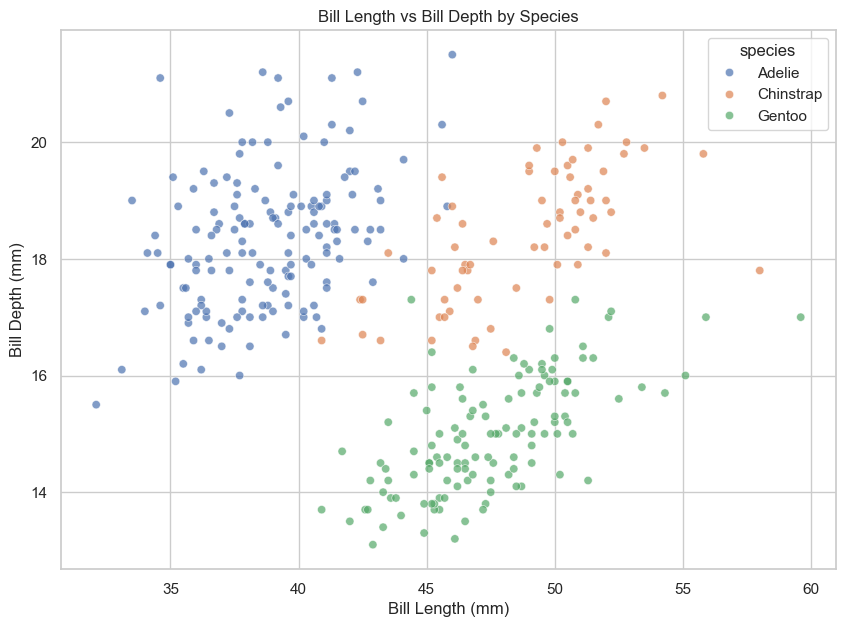

In [11]:
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, x="bill_length_mm", y="bill_depth_mm", hue="species", alpha=0.7)
plt.title("Bill Length vs Bill Depth by Species")
plt.xlabel("Bill Length (mm)")
plt.ylabel("Bill Depth (mm)")
plt.show()

**Answer:**

The colors reveal three distinct clusters separated by species. A plain scatter plot shows a single messy cloud with no obvious pattern, hiding the fact that each species occupies a different region of the bill length-bill depth space. Adelie penguins have short bills with medium depth, Chinstrap have longer bills with medium depth, and Gentoo have long bills with shallow depth. The colors also reveal that within each species, bill length and bill depth are positively correlated, while the overall correlation across all species is negative.



### **3. Build a cross-tab of species vs. island with row percentages (normalize="index"). Which island is home to only one species?**

In [17]:
crosstab = pd.crosstab(df["species"], df["island"], normalize="index")
print(crosstab.round(3))

crosstab_counts = pd.crosstab(df["species"], df["island"])
crosstab_pct = pd.crosstab(df["species"], df["island"], normalize="index").round(3)
print("Counts:")
print(crosstab_counts)
print("\nRow percentages:")
print(crosstab_pct)

island     Biscoe  Dream  Torgersen
species                            
Adelie      0.289  0.368      0.342
Chinstrap   0.000  1.000      0.000
Gentoo      1.000  0.000      0.000
Counts:
island     Biscoe  Dream  Torgersen
species                            
Adelie         44     56         52
Chinstrap       0     68          0
Gentoo        124      0          0

Row percentages:
island     Biscoe  Dream  Torgersen
species                            
Adelie      0.289  0.368      0.342
Chinstrap   0.000  1.000      0.000
Gentoo      1.000  0.000      0.000


**Answer:**

Only Torgersen Island has a single species.

### **4. Make a box plot of body_mass_g split by sex (x="sex"). Do males or females tend to be heavier?**

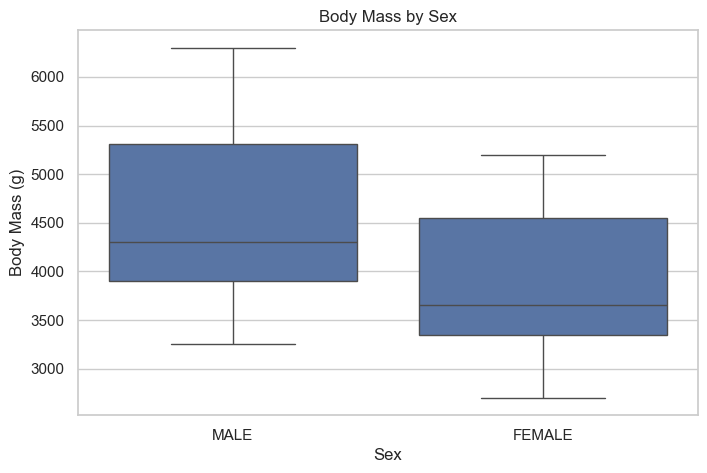

sex
FEMALE    3862.3
MALE      4545.7
Name: body_mass_g, dtype: float64


In [23]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="sex", y="body_mass_g")
plt.title("Body Mass by Sex")
plt.xlabel("Sex")
plt.ylabel("Body Mass (g)")
plt.show()

sex_means = df.groupby("sex")["body_mass_g"].mean()
print(sex_means.round(1))

**Answer:**

Males tend to be heavier.

### **5. Does one number tell the truth? From the correlation heatmap, name the strongest relationship and report its value. Then take bill_length_mm vs. bill_depth_mm — the heatmap shows a weak negative number. Make that scatter coloured by species. Does the single correlation value honestly summarise the relationship? Connect your answer to Simpson's paradox.**

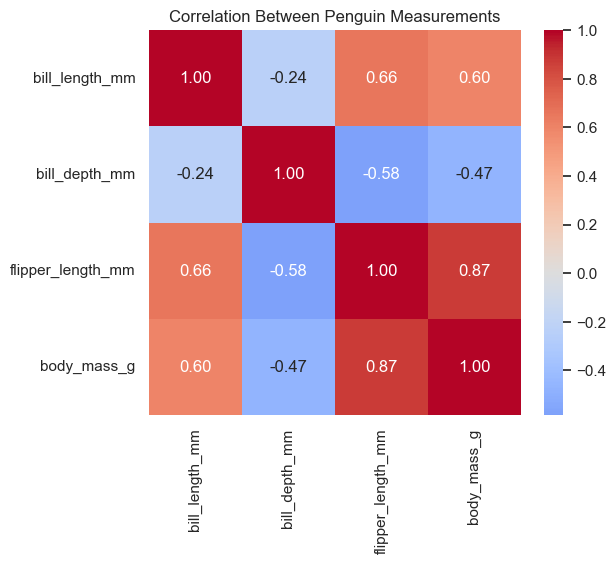

Strongest relationship: flipper_length_mm  body_mass_g    0.871202
dtype: float64


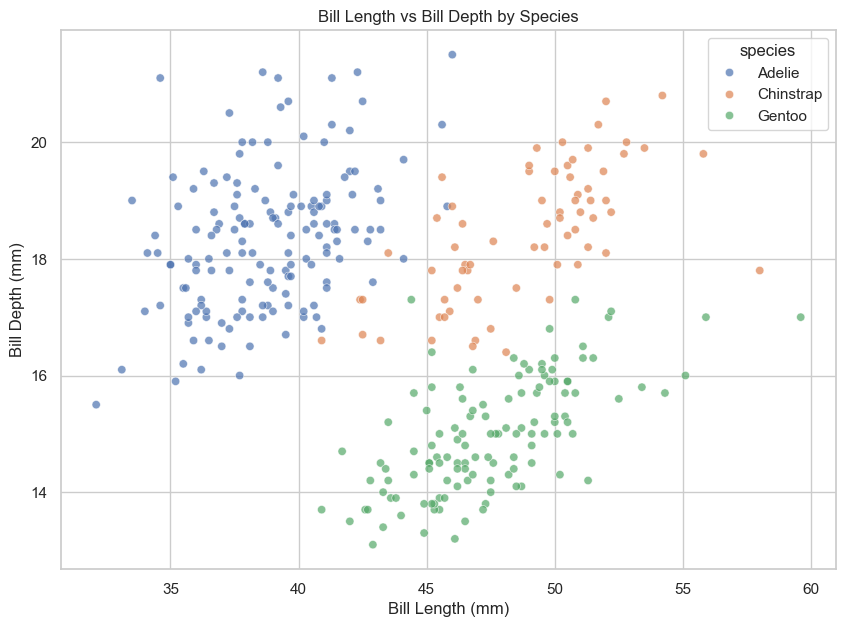

In [31]:
corr = df.select_dtypes("number").corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Between Penguin Measurements")
plt.show()

strongest_pair = corr.unstack().sort_values(ascending=False)
strongest_pair = strongest_pair[strongest_pair < 0.999].head(1)
print(f"Strongest relationship: {strongest_pair}")

plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, x="bill_length_mm", y="bill_depth_mm", hue="species", alpha=0.7)
plt.title("Bill Length vs Bill Depth by Species")
plt.xlabel("Bill Length (mm)")
plt.ylabel("Bill Depth (mm)")
plt.show()

**Answer**

The strongest relationship is between flipper_length_mm and body_mass_g (correlation = 0.87).

The single correlation value for bill_length_mm vs. bill_depth_mm is weakly negative (-0.24). However, the scatter plot colored by species shows that every species actually has a positive correlation within its group. The single correlation value does NOT honestly summarize the relationship — it hides the true pattern. This is Simpson's paradox: a lurking variable reverses the direction of the correlation when looking at the aggregated data versus the grouped data. Without coloring by species, you would incorrectly conclude that longer bills are associated with shallower depth, when in fact the opposite is true within each species. 

### **6. Challenge (make the paradox undeniable): Recreate the sns.lmplot from Section 6, then also fit a single trend line to the pooled data with sns.regplot(data=df, x="bill_length_mm", y="bill_depth_mm", scatter=False). Put both in one sentence: which way does the pooled line slope, and which way do the per-species lines slope?** 

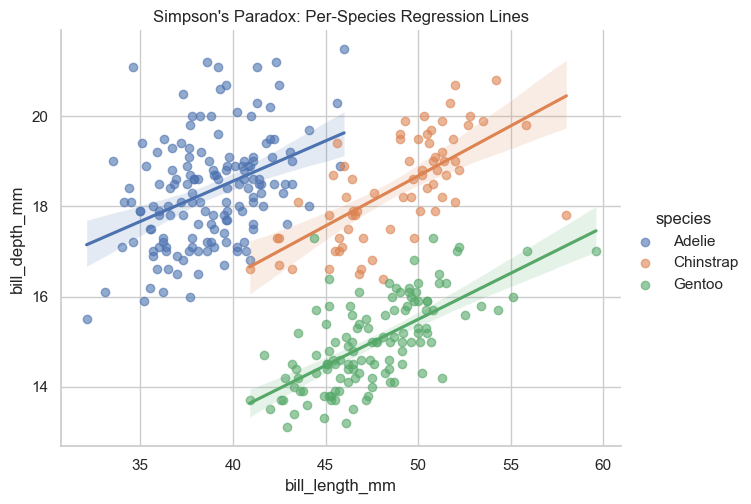

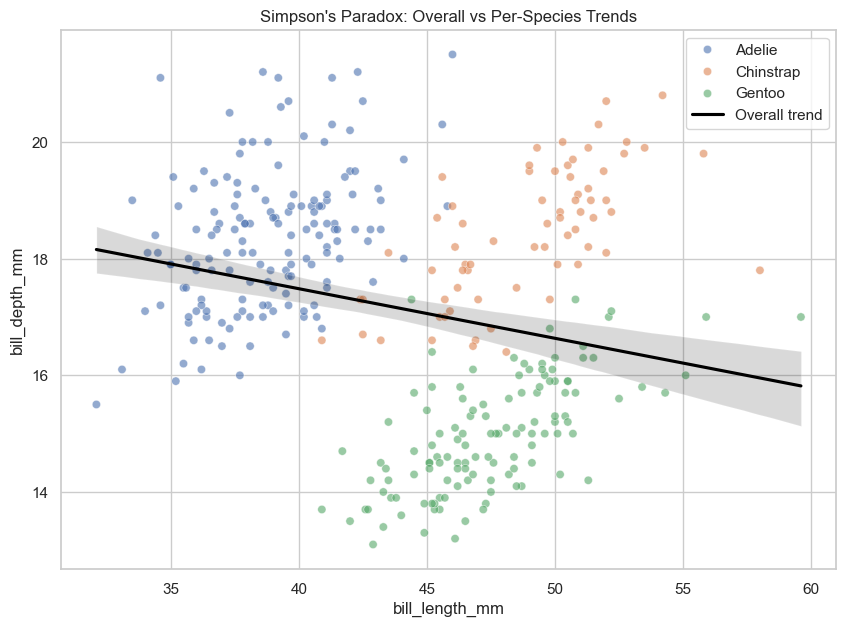

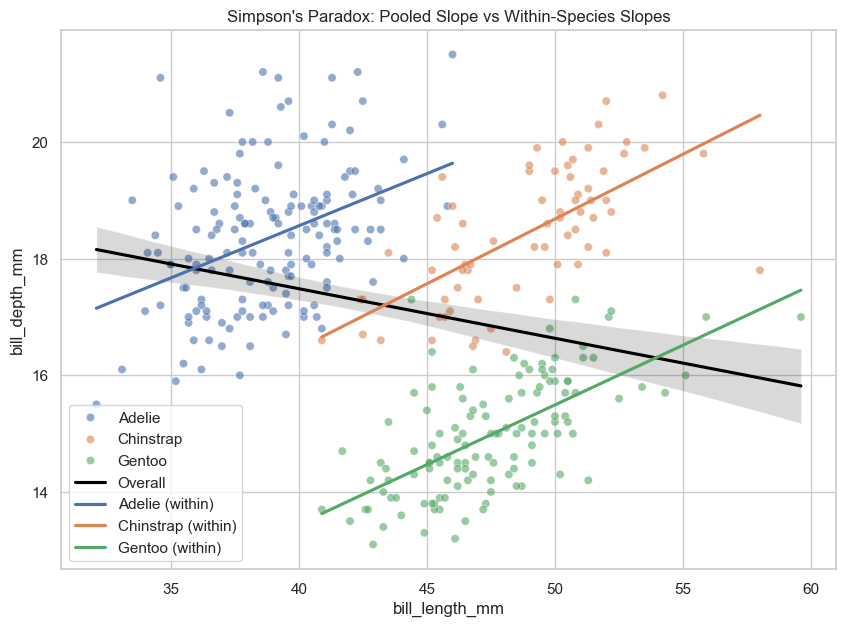

In [38]:
sns.lmplot(data=df, x="bill_length_mm", y="bill_depth_mm", hue="species", 
           height=5, aspect=1.3, scatter_kws={"alpha": 0.6})
plt.title("Simpson's Paradox: Per-Species Regression Lines")
plt.show()

plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, x="bill_length_mm", y="bill_depth_mm", hue="species", alpha=0.6)
sns.regplot(data=df, x="bill_length_mm", y="bill_depth_mm", scatter=False, color="black", label="Overall trend")
plt.title("Simpson's Paradox: Overall vs Per-Species Trends")
plt.legend()
plt.show()

plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, x="bill_length_mm", y="bill_depth_mm", hue="species", alpha=0.6)
sns.regplot(data=df, x="bill_length_mm", y="bill_depth_mm", scatter=False, color="black", label="Overall")
for species in df["species"].unique():
    subset = df[df["species"] == species]
    sns.regplot(data=subset, x="bill_length_mm", y="bill_depth_mm", scatter=False, 
                label=f"{species} (within)", ci=None)
plt.title("Simpson's Paradox: Pooled Slope vs Within-Species Slopes")
plt.legend()
plt.show()

**Answer:**

The pooled line slopes downward (negative), while the per-species lines all slope upward (positive).

